In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)


In [ ]:
import pandas as pd
df = pd.read_csv('/content/online.csv')
df.head()

,id_student,gender,region,highest_education,studied_credits,imd_band,total_clicks,avg_score,engagement_level,performance_level,risk_level,pass_flag,dropout_flag,final_result
0,11391,M,East Anglian Region,HE Qualification,240,90-100%,934.0,82.0,Medium,High,Low Risk,1,0,Pass
1,28400,F,Scotland,HE Qualification,60,20-30%,1435.0,66.4,Medium,Medium,Low Risk,1,0,Pass
2,30268,F,North Western Region,A Level or Equivalent,60,30-40%,281.0,NaN,Low,NaN,Very High Risk,0,1,Withdrawn
3,31604,F,South East Region,A Level or Equivalent,60,50-60%,2158.0,76.0,High,High,Low Risk,1,0,Pass
4,32885,F,West Midlands Region,Lower Than A Level,60,50-60%,1034.0,54.4,Medium,Medium,Low Risk,1,0,Pass


In [ ]:
df["final_result"].value_counts()

,count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


In [ ]:
df.groupby("engagement_level")["pass_flag"].mean()

,pass_flag
engagement_level,
High,0.781354
Low,0.199194
Medium,0.571530


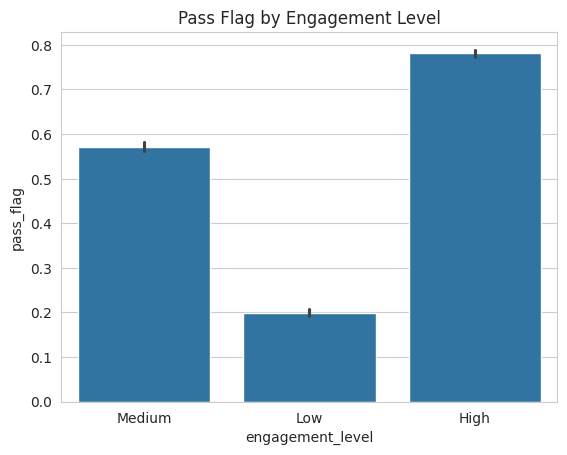

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="engagement_level", y="pass_flag", data=df)
plt.title("Pass Flag by Engagement Level")
sns.set_style("whitegrid")
plt.show()

In [ ]:
df

,id_student,gender,region,highest_education,studied_credits,imd_band,total_clicks,avg_score,engagement_level,performance_level,risk_level,pass_flag,dropout_flag,final_result
0,11391,M,East Anglian Region,HE Qualification,240,90-100%,934.0,82.000000,Medium,High,Low Risk,1,0,Pass
1,28400,F,Scotland,HE Qualification,60,20-30%,1435.0,66.400000,Medium,Medium,Low Risk,1,0,Pass
2,30268,F,North Western Region,A Level or Equivalent,60,30-40%,281.0,NaN,Low,NaN,Very High Risk,0,1,Withdrawn
3,31604,F,South East Region,A Level or Equivalent,60,50-60%,2158.0,76.000000,High,High,Low Risk,1,0,Pass
4,32885,F,West Midlands Region,Lower Than A Level,60,50-60%,1034.0,54.400000,Medium,Medium,Low Risk,1,0,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32588,2640965,F,Wales,Lower Than A Level,30,Oct-20,41.0,NaN,Low,NaN,Very High Risk,0,0,Fail
32589,2645731,F,East Anglian Region,Lower Than A Level,30,40-50%,893.0,88.111111,Medium,High,High Risk,1,0,Distinction
32590,2648187,F,South Region,A Level or Equivalent,30,20-30%,312.0,76.666667,Low,High,Very High Risk,1,0,Pass
32591,2679821,F,South East Region,Lower Than A Level,30,90-100%,275.0,91.500000,Low,High,Very High Risk,0,1,Withdrawn


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Create dummy y_test and y_pred for demonstration purposes
# In a real scenario, these would be the actual test labels and model predictions
# Assuming a binary classification task based on 'pass_flag' for demonstration

# Filter out NaN values from 'pass_flag' to ensure valid targets
df_filtered = df.dropna(subset=['pass_flag'])

y = df_filtered['pass_flag']
X = df_filtered.drop(columns=['pass_flag']) # X is not used here but needed for train_test_split convention

# Split data to get appropriate sizes for y_test and y_pred
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Create dummy predictions (y_pred) for the test set, matching the distribution of y_test
# For simplicity, let's just use random predictions that are similar to y_test
y_pred = np.random.randint(0, 2, size=y_test.shape)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.4916138269584782

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.49      0.51      5162
           1       0.46      0.49      0.48      4616

    accuracy                           0.49      9778
   macro avg       0.49      0.49      0.49      9778
weighted avg       0.49      0.49      0.49      9778


Confusion Matrix:
[[2550 2612]
 [2359 2257]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

# Select only numerical features for initial model training
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
X_train_numeric = X_train[numerical_cols]
X_test_numeric = X_test[numerical_cols]

# Impute missing values in numerical columns (e.g., 'avg_score')
imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_numeric), columns=numerical_cols, index=X_train_numeric.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_numeric), columns=numerical_cols, index=X_test_numeric.index)

# Train a RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_imputed, y_train)

importance = pd.DataFrame({
    'Feature': X_train_imputed.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features:")
print(importance.head(10))


Top Important Features:
           Feature  Importance
4     dropout_flag    0.326174
3        avg_score    0.281410
2     total_clicks    0.247011
0       id_student    0.118419
1  studied_credits    0.026987


<Axes: xlabel='engagement_level', ylabel='pass_flag'>

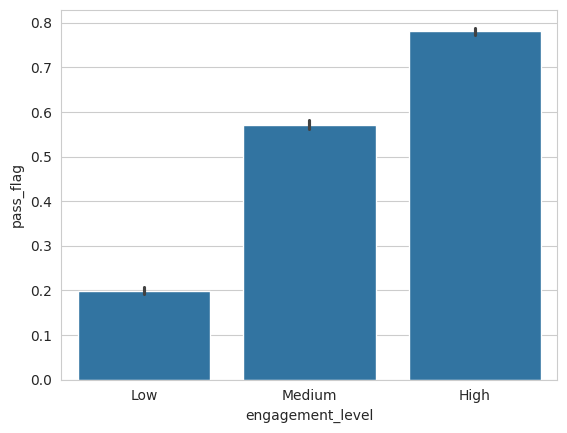

In [ ]:
sns.barplot(
    x="engagement_level",
    y="pass_flag",
    data=df,
    order=["Low","Medium","High"]
)